# Basic EDA - Time Series

In [1]:
# Import libraries for data manipulation, stats, and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## 1. Load & Inspect Data

In [2]:
# Load CSV, parse dates, set daily frequency
df = pd.read_csv('data/timeseries.csv', parse_dates=['date'], index_col='date')
df = df.asfreq('D')

print(f'Shape: {df.shape}')
df.head()

Shape: (454, 1)


,unit_sales
date,
2013-01-02,582.0
2013-01-03,310.0
2013-01-04,338.0
2013-01-05,654.0
2013-01-06,979.0


In [3]:
# Summary statistics (count, mean, min, quartiles, max)
df.describe()

,unit_sales
count,452.000000
mean,480.090708
std,170.839776
min,4.000000
25%,358.000000
50%,445.500000
75%,578.250000
max,1203.000000


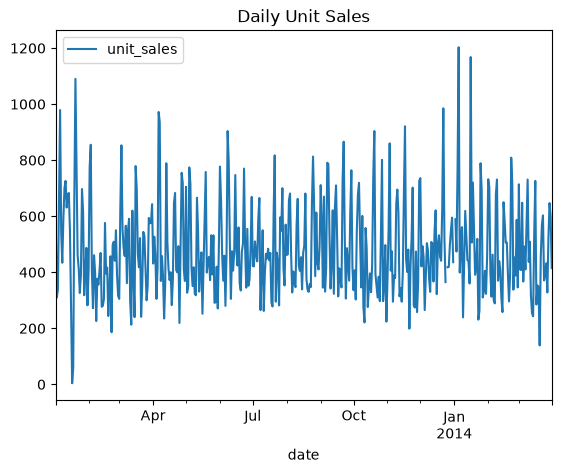

In [4]:
# Visualise the full series to spot trends and patterns
df.plot(title='Daily Unit Sales')
plt.show()

## 2. Handle Outliers & Missing Values

In [5]:
# Cap outliers via IQR, forward/backward fill missing values
Q1, Q3 = df['unit_sales'].quantile([0.25, 0.75])
lower, upper = Q1 - 1.5 * (Q3 - Q1), Q3 + 1.5 * (Q3 - Q1)
print(f'Outliers: {((df["unit_sales"] < lower) | (df["unit_sales"] > upper)).sum()}')

df['unit_sales'] = df['unit_sales'].clip(lower, upper).ffill().bfill()
print(f'Missing after fill: {df.isnull().sum().values[0]}')

Outliers: 9
Missing after fill: 0


## 3. Seasonal Decomposition

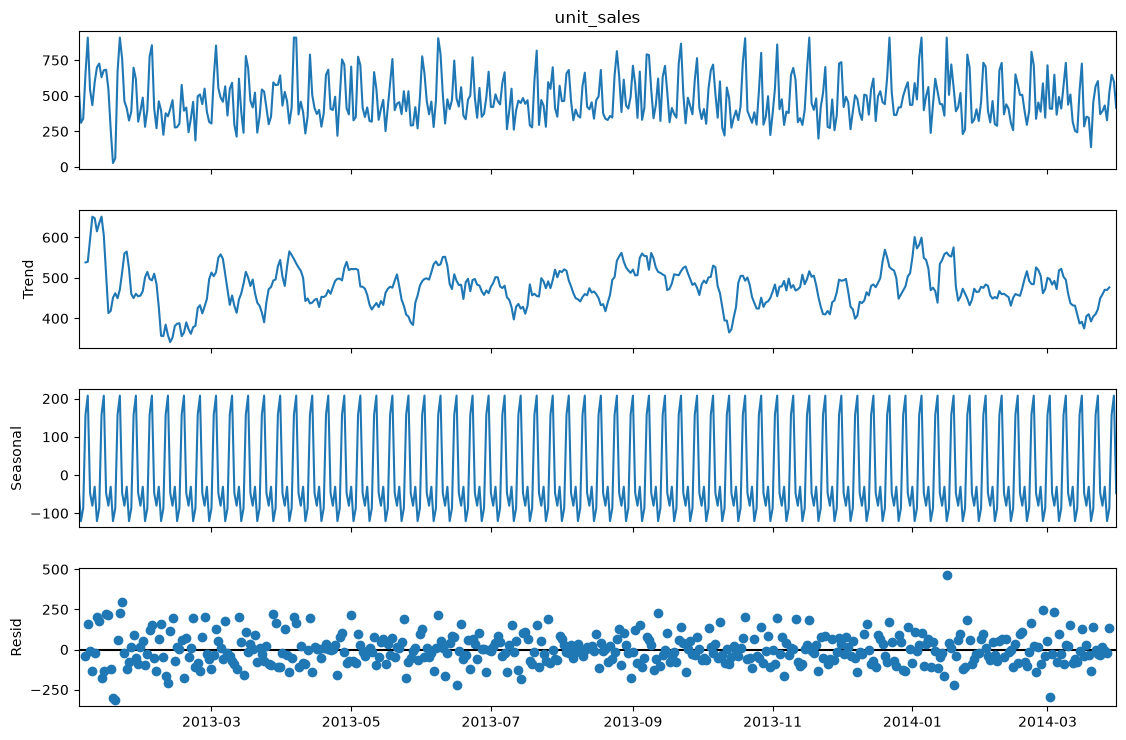

In [6]:
# Decompose into trend, seasonal (7-day), and residual components
fig = seasonal_decompose(df['unit_sales'], model='additive', period=7).plot()
fig.set_size_inches(12, 8)
plt.show()

## 4. Stationarity (ADF Test)

In [7]:
# Augmented Dickey-Fuller test for stationarity
result = adfuller(df['unit_sales'].dropna())
print(f'ADF: {result[0]:.4f}, p-value: {result[1]:.4f}')
print('Stationary' if result[1] < 0.05 else 'Non-stationary')

ADF: -5.2185, p-value: 0.0000
Stationary


## 5. ACF & PACF

**ACF (Autocorrelation Function):** shows correlation between the series and its lagged values (including indirect effects propagated through intermediate lags)

**PACF (Partial Autocorrelation Function):** shows the direct correlation at each lag, controlling for shorter lags.

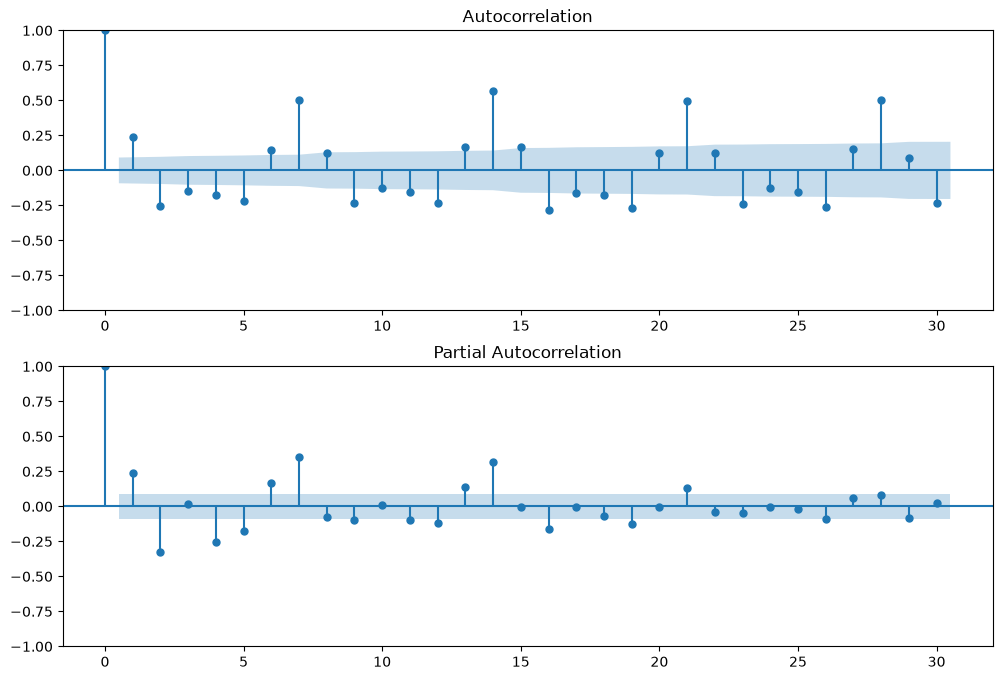

In [8]:
# Autocorrelation and partial autocorrelation (up to 30 lags)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['unit_sales'], lags=30, ax=ax1)
plot_pacf(df['unit_sales'], lags=30, ax=ax2)
plt.show()

Significant bars beyond the blue confidence band indicate important lags

ACF — Slow, oscillating decay with strong positive spikes at lags 7, 14, 21, 28 (~0.5 each). Indicates weekly seasonality and that the series is non-stationary (needs differencing) because the autocorrelation doesn't cut off sharply.

PACF — Significant spikes at lags 1 (0.24), 2 (-0.33), then a cutoff; plus significant seasonal spikes at lags 7, 14, 21, 28. Suggests an AR(2) + seasonal AR(1) structure — i.e., SARIMA(p=2,d=1,q=0)(P=1,D=1,Q=0,S=7) would be a reasonable starting model

## 6. Save Cleaned Data

In [9]:
# Export cleaned dataset for downstream models
df.to_csv('data/cleaned_timeseries.csv')
print('Saved to data/cleaned_timeseries.csv')

Saved to data/cleaned_timeseries.csv
